# Using LOB information to predict short term price movements 

This notebook explores how we can use LOB data (up to 20 levels) and various machine learning/deep learning models to predict short term price movements in BTC. 

Of particular interest: 
1. How much PREDICTIVE power improvement it gives us over just using the instantaneous order book imbalance? 
2. How can we CONVERT the decision tree model to a trading strategy

In [1]:
%load_ext autoreload
%autoreload 2

import lakeapi
import datetime as dt
from datetime import timedelta, datetime, date, time
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import plotly.graph_objects as go 
import mplfinance as mpf
from scipy.stats import pearsonr
from itertools import product

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100)

from xgboost import plot_importance

In [2]:
START = dt.datetime(year = 2025, month = 10, day = 1)
END = dt.datetime(year = 2026, month = 2, day = 1)

# raw_df = lakeapi.load_data(
#     table="book",
#     start=START,
#     end=END,
#     symbols=["BTC-USDT"],
#     exchanges=["BINANCE"]
# )
# raw_df.to_parquet("data/crypto_book_raw_data.parquet")
# raw_df = pd.read_parquet("data/crypto_book_1min_data.parquet")

raw_df = pd.read_parquet("data/crypto_book_1min_data.parquet")

In [ ]:
# Global Variables 

HOLDING_PERIODS = [1, 3, 5, 10, 60, 720]

# Basic Data Cleaning 

In [26]:
raw_df.origin_time.min()
raw_df.origin_time.max()

raw_df.received_time.min()
raw_df.received_time.max()

len(raw_df)

Timestamp('1970-01-01 00:00:00')

Timestamp('2025-12-31 23:59:00.013999872')

Timestamp('2025-01-01 00:00:00.020465408')

Timestamp('2025-12-31 23:59:00.024932352')

520468

In [4]:
raw_df['timestamp'] = raw_df['origin_time'].mask(raw_df['origin_time'].dt.year == 1970, pd.NaT)

In [66]:
raw_df['timestamp'].min()
raw_df['timestamp'].max()
raw_df['timestamp'].isna().sum()

Timestamp('2025-01-01 00:00:00.013999872')

Timestamp('2025-12-31 23:59:00.013999872')

np.int64(16)

In [67]:
raw_df[raw_df['timestamp'].isna()].received_time

22382    2025-01-16 13:00:01.872619008
59150    2025-02-11 01:43:01.676749824
130175   2025-04-01 09:13:04.878860288
135375   2025-04-04 23:53:01.676777984
153949   2025-04-17 21:25:01.736145920
331031   2025-08-18 20:15:01.414662912
337385   2025-08-23 06:08:44.565085440
361883   2025-09-09 06:33:28.114055936
362930   2025-09-13 14:30:21.869468416
362931   2025-09-13 14:32:39.954820864
412587   2025-10-18 01:58:01.870119936
431311   2025-10-31 01:59:01.681115392
470756   2025-11-27 11:20:05.388537600
504141   2025-12-20 15:53:05.968521728
504142   2025-12-20 15:55:13.358848512
504144   2025-12-20 15:59:38.463858176
Name: received_time, dtype: datetime64[ns]

In [5]:
df= raw_df.resample('1min', on='timestamp').last()
len(df)

525600

In [9]:
mask = df['ask_0_price'].isna()
df[mask].groupby(df[mask].index.date).size().sort_values(ascending=False)

2025-09-12    1440
2025-09-11    1440
2025-09-10    1440
2025-09-13     873
2025-12-20      18
2025-09-09      16
2025-03-19       4
2025-01-06       4
2025-04-07       3
2025-04-09       2
2025-04-02       2
2025-05-21       2
2025-02-17       2
2025-06-16       2
2025-03-05       2
2025-04-16       2
2025-03-20       2
2025-08-23       2
2025-01-16       2
2025-07-02       1
2025-08-18       1
2025-01-27       1
2025-01-21       1
2025-01-22       1
2025-06-03       1
2025-01-18       1
2025-09-29       1
2025-10-18       1
2025-10-20       1
2025-10-31       1
2025-11-06       1
2025-11-27       1
2025-11-28       1
2025-06-13       1
2025-02-11       1
2025-05-25       1
2025-03-27       1
2025-02-18       1
2025-02-21       1
2025-02-25       1
2025-03-07       1
2025-02-02       1
2025-03-21       1
2025-03-25       1
2025-03-29       1
2025-05-23       1
2025-03-31       1
2025-04-01       1
2025-04-04       1
2025-04-08       1
2025-01-12       1
2025-04-17       1
2025-04-21  

We have a chunk of missing data for a couple of days in September and after that the data issues are minimal. 

<Axes: xlabel='timestamp'>

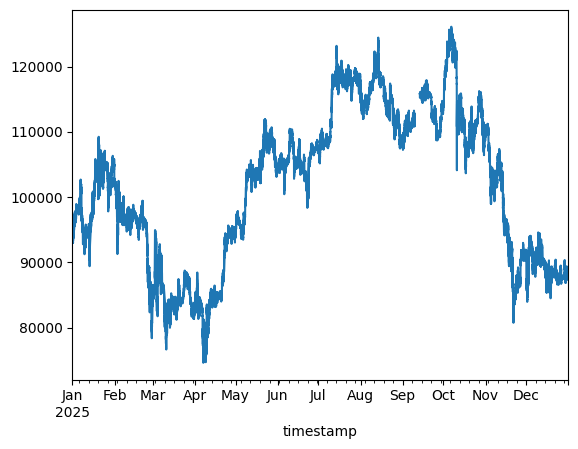

In [10]:
df['ask_0_price'].plot()

# Initial Data Analysis 

Some initial plots/data analysis to get a sense of what kind of machine learning model we need to build. See Part 1 notebook for context. 

Of particular concern is the frequency with which we want to retrain our model (online learning). 

In [12]:
from test_momentum import calc_obi_corr

In [3]:
df['obi'] = (df['bid_0_size'] - df['ask_0_size']) / (df['bid_0_size'] + df['ask_0_size'])
df['mid'] = (df['ask_0_price'] + df['bid_0_price'])/2

for horizon in HOLDING_PERIODS: 
        #Calculate forward returns 
        df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)

NameError: name 'df' is not defined

In [8]:
#Calculate correlations 
calc_obi_corr(holding = HOLDING_PERIODS, df = df)

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /test_momentum.py:131: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_ret = df['mid'].pct_change(horizon).shift(-horizon)


,correlation,pvalue,n
holding_period,,,
1,0.098817,0.000000e+00,520306.0
3,0.054513,2.926652e-114,173432.0
5,0.042358,1.538274e-42,104056.0
10,0.026263,2.082261e-09,52027.0
60,0.014176,1.868699e-01,8671.0
720,-0.087718,1.848169e-02,721.0


There is a surprisingly weaker correlation using overall 1 minute frequency data. Is it because it's rolling? 


Text(0.5, 0, 'Time')

Text(0, 0.5, 'Correlation')

Text(0.5, 1.0, 'Rolling 0.5d Correlation')

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Correlation')

Text(0.5, 1.0, 'Rolling 1d Correlation')

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Correlation')

Text(0.5, 1.0, 'Rolling 7d Correlation')

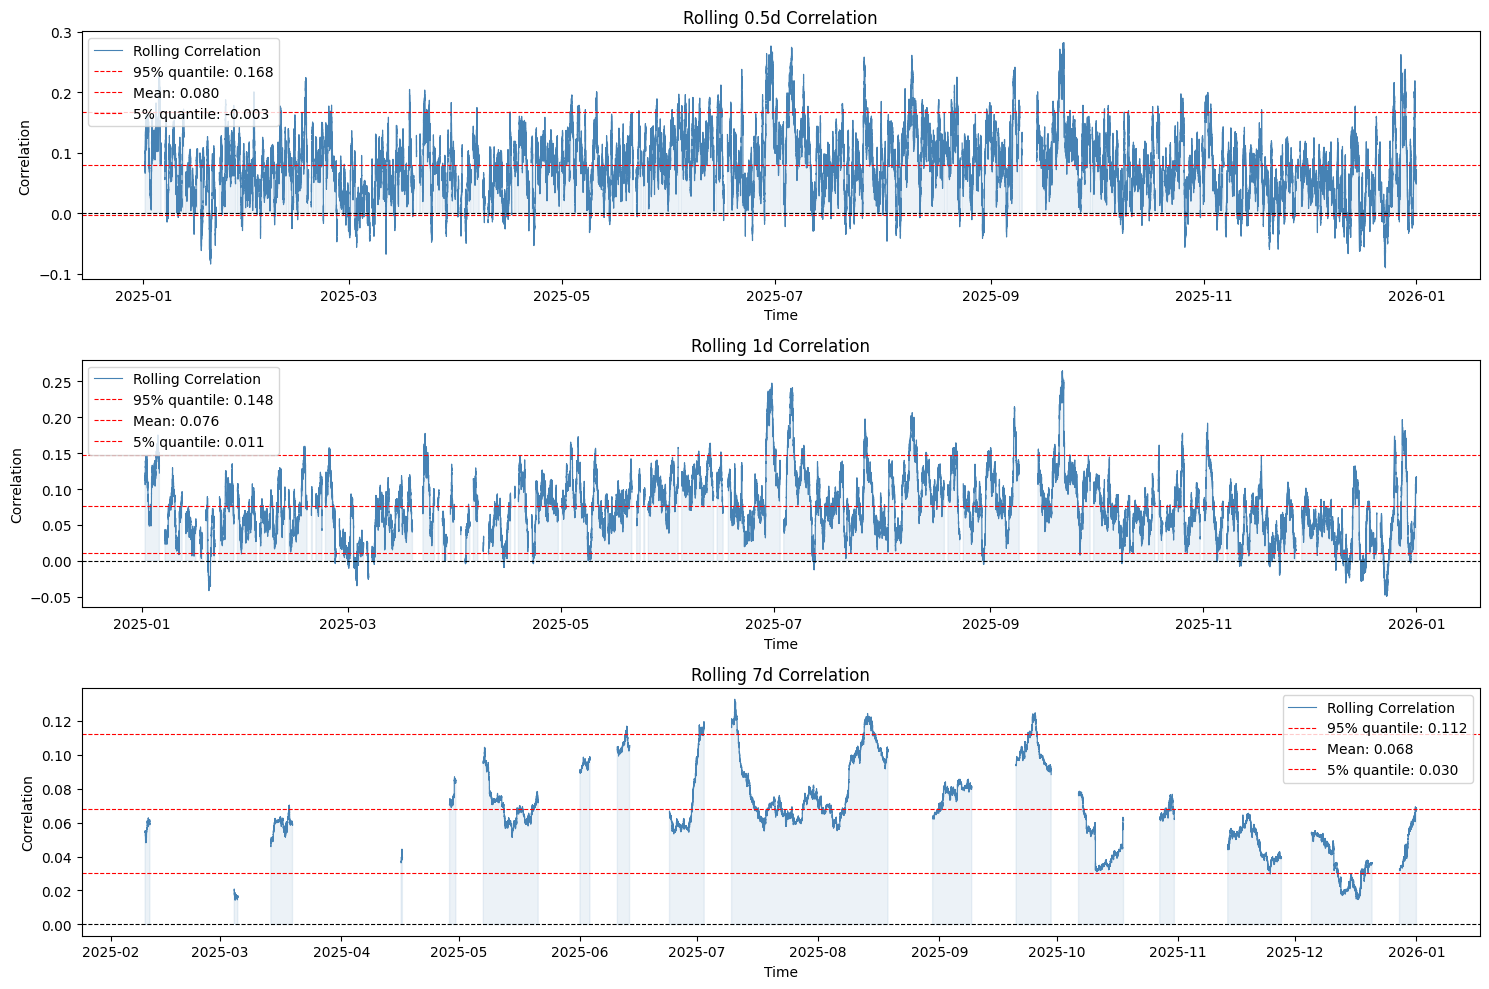

In [10]:
MINUTES_IN_DAY = 1440
holding = 2
rolling = [0.5, 1, 7]

fig, ax = plt.subplots(3, figsize=(15, 10))  # increased height

for a, lb in zip(ax, rolling):
    lookback = int(lb * MINUTES_IN_DAY)
    roll_corr = df['obi'].rolling(lookback).corr(df['fwd_ret_3'])
    
    a.plot(roll_corr, label='Rolling Correlation', color='steelblue', linewidth=0.8)
    a.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    a.axhline(y=roll_corr.quantile(0.95), color='red', linewidth=0.8, linestyle='--',
              label=f'95% quantile: {roll_corr.quantile(0.95):.3f}')
    a.axhline(y=roll_corr.mean(), color='red', linewidth=0.8, linestyle='--',
              label=f'Mean: {roll_corr.mean():.3f}')
    a.axhline(y=roll_corr.quantile(0.05), color='red', linewidth=0.8, linestyle='--',
              label=f'5% quantile: {roll_corr.quantile(0.05):.3f}')
    a.fill_between(roll_corr.index, roll_corr, 0, alpha=0.1, color='steelblue')
    
    a.set_xlabel('Time')       # fixed: was a.xlabel
    a.set_ylabel('Correlation') # fixed: was a.ylabel
    a.set_title(f'Rolling {lb}d Correlation')  # optional but helpful
    a.legend()

plt.tight_layout()
plt.show()

Even accounting for rolling correlation, the relationship is still weaker than at 10 second frequency. 

# 10 second frequency data 

In [10]:
HOLDING_PERIODS =  [3, 6, 18, 30, 60, 120, 300]

In [49]:
# raw_df = pd.read_parquet("data/crypto_book_raw_data.parquet")
# raw_df['timestamp'] = raw_df['origin_time'].mask(raw_df['origin_time'].dt.year == 1970, pd.NaT)
# df= raw_df.resample('10s', on='timestamp').last()
# df.to_parquet("data/crypto_book_10s_data.parquet")

raw_df = pd.read_parquet("data/crypto_book_10s_data.parquet")

In [12]:
raw_df.index.min()
raw_df.index.max()

Timestamp('2025-10-01 00:00:00')

Timestamp('2026-01-31 23:59:50')

In [138]:
mask = raw_df['ask_0_price'].isna()
raw_df[mask].groupby(raw_df[mask].index.date).size().sort_values(ascending=False)

2025-12-20    101
dtype: int64

In [50]:
df = raw_df.copy()

In [51]:
df['obi'] = (df['bid_0_size'] - df['ask_0_size']) / (df['bid_0_size'] + df['ask_0_size'])
df['mid'] = (df['ask_0_price'] + df['bid_0_price'])/2

for horizon in HOLDING_PERIODS: 
        #Calculate forward returns 
        df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)

/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_24182/1506306024.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)
/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_24182/1506306024.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)
/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_24182/1506306024.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version.

In [151]:
calc_obi_corr(holding = [1, 3, 6, 18, 30, 60, 120, 300], df = df)

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /test_momentum.py:131: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_ret = df['mid'].pct_change(horizon).shift(-horizon)


,correlation,pvalue,n
holding_period,,,
1,0.182380,0.000000e+00,1062618.0
3,0.125286,0.000000e+00,354206.0
6,0.093076,0.000000e+00,177102.0
18,0.054480,4.739599e-40,59033.0
30,0.040760,1.665855e-14,35420.0
60,0.034544,4.262364e-06,17710.0
120,0.027159,1.059446e-02,8855.0
300,0.028954,8.494477e-02,3541.0


# Targets/Features 

We will start by brainstorming a set of features that incorporate information from **ALL** of the order book data. 

In [52]:
ROLLING = [1, 3, 6, 10, 30, 60, 120, 300]
feas_list = ['obi']

In [53]:
df.columns

Index(['origin_time', 'received_time', 'sequence_number', 'bid_0_price',
       'bid_0_size', 'bid_1_price', 'bid_1_size', 'bid_2_price', 'bid_2_size',
       'bid_3_price', 'bid_3_size', 'bid_4_price', 'bid_4_size', 'bid_5_price',
       'bid_5_size', 'bid_6_price', 'bid_6_size', 'bid_7_price', 'bid_7_size',
       'bid_8_price', 'bid_8_size', 'bid_9_price', 'bid_9_size',
       'bid_10_price', 'bid_10_size', 'bid_11_price', 'bid_11_size',
       'bid_12_price', 'bid_12_size', 'bid_13_price', 'bid_13_size',
       'bid_14_price', 'bid_14_size', 'bid_15_price', 'bid_15_size',
       'bid_16_price', 'bid_16_size', 'bid_17_price', 'bid_17_size',
       'bid_18_price', 'bid_18_size', 'bid_19_price', 'bid_19_size',
       'ask_0_price', 'ask_0_size', 'ask_1_price', 'ask_1_size', 'ask_2_price',
       'ask_2_size', 'ask_3_price', 'ask_3_size', 'ask_4_price', 'ask_4_size',
       'ask_5_price', 'ask_5_size', 'ask_6_price', 'ask_6_size', 'ask_7_price',
       'ask_7_size', 'ask_8_price', 'ask

In [54]:
#instantaneous features 
##order size 
df['total_bid_size'] = df[[f'bid_{level}_size' for level in range(20)]].sum(axis=1)
df['total_ask_size'] = df[[f'ask_{level}_size' for level in range(20)]].sum(axis=1)
df['total_size'] = df['total_bid_size'] + df['total_ask_size']
df['total_imbalance'] = (df['total_bid_size'] - df['total_ask_size'])/df['total_size']

feas_list.extend(['total_imbalance'])

##bid/ask spread 
df['bid_ask_spread_0'] = (df['ask_0_price']-df['bid_0_price'])/df['ask_0_price']

feas_list.extend(['bid_ask_spread_0'])

#smoothed 
##order size 
for r in ROLLING: 
    df[f'rolling_obi_{r}']=df['obi'].rolling(r).mean()
    df[f'rolling_total_imbalance_{r}']= df['total_imbalance'].rolling(r).mean()
    feas_list.extend([f'rolling_obi_{r}', 
                      f'rolling_total_imbalance_{r}'
                      ])
##price 
for r in ROLLING: 
    col_name = f'rolling_bid_ask_spread_{r}'
    df[col_name] = df['bid_ask_spread_0'].rolling(r).mean()
    feas_list.append(col_name)

#momentum 
##obi
###velocity 
df[f'obi_velocity']= df['obi'].diff()
df[f'total_imbalance_velocity']= df['total_imbalance'].diff()
###acceleration
df[f'obi_acc'] = df['obi'].diff().diff()
df[f'total_imbalance_acc'] = df['total_imbalance'].diff().diff()

feas_list.extend(['obi_velocity', 
                  'total_imbalance_velocity', 
                  'obi_acc', 
                  'total_imbalance_acc'
                  ])

#smoothed velocity 
#TODO - How can we make the rolling averages smoother? 
for r in ROLLING: 
    df[f'rolling_obi_{r}_velocity'] = df[f'rolling_obi_{r}'].diff()
    df[f'rolling_total_imbalance_{r}_velocity'] = df[f'rolling_total_imbalance_{r}'].diff()
    feas_list.extend([
        f'rolling_obi_{r}_velocity', 
        f'rolling_total_imbalance_{r}_velocity'
    ])

##price momentum 
df['bid_ask_spread_0_velocity'] = df['bid_ask_spread_0'].diff()
feas_list.extend([
    'bid_ask_spread_0_velocity'
])
##boolean flags
df['imbalance_flag'] = (df['obi'] > 0).astype('category')
feas_list.extend([
    'imbalance_flag'
])

Note about Boolean features: 
Of particular importance is that we should be able to at least reliably predict the DIRECTION of the order flow - the "momentum" aspect is that the buy side or sell side imbalance predicts positive/negative price movements, respectively. 

TODO: It is an open question of how we might bake this into the loss function, but what we can also do is make a boolean feature. 

In [55]:
len(feas_list)

49

# Decision Tree Modelling 
Our parameters of interest 
- Retraining window - see Plot from part 1 notebook which shows rolling correlation plot
  - What is the most sensible split for frequent model retraining? 
- Time series split - use the expanding window method
- What features are most informative? 
- What model is most informative - does non-linear decision tree help? Or is linear model better? 
- Consider - doing a sliding window split with overlapping rows 
- How would we EVALUATE the model vs. how would we TRAIN the model? What objective function to use? 
- What should be the retraining period for the model? 
  - This is an interesting question. 
- Decision tree modelling - how to tell if improvements are statistically significant? 

In [17]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

In [18]:
def train_test_split(df: pd.DataFrame, num_splits: int = 10, split_ratio = 0.8) -> list[(pd.Index, pd.Index)]: 
    '''Prepare time series for k-fold validation. No supersets. '''
    numbered_index = np.arange(len(df))
    chunks = np.array_split(numbered_index, num_splits) #use positional index instead 
    tss = [
        (c[0:int(len(c)*split_ratio)], c[int(len(c)*split_ratio):]) #split up into train, test splits 
        for c in chunks 
    ]
    return tss 

In [19]:
#we want a rollign implementation 
def rolling_cv_split(data_length: int, train_size, test_size, step_size = None): 
    if step_size is None: 
        step_size = test_size
    numbered_index = np.arange(data_length)
    splits = []
    start_idx = range(0, data_length - train_size - test_size + 1, step_size)
    for start in start_idx: 
        train_idx = numbered_index[start: start + train_size]
        val_idx = numbered_index[start+train_size : start + train_size + test_size]
        splits.append((train_idx, val_idx))
    
    print(f"Number of total test samples: {len(splits)}")
    return splits

In [69]:
def sliding_window_cross_val(df: pd.DataFrame, 
                             features: list[str], 
                             target: str,
                             xgb_params: dict = None,
                             num_splits: int = 10, 
                             split_ratio: float = 0.8,
                            train_size: int = None,
                             test_size: int = None,
                             model_type: str = 'xgb',  # 'xgb' or 'linear'
                             cv: str = 'split' # 'rolling' or #expand 
                             ): 
    val_scores = []
    train_scores = []
    models = []

    clean_df = df[df[target].notna()]
    expected = pd.Timedelta(seconds=10)
    bad_gaps = clean_df.index.to_series().diff().dropna()
    if not (bad_gaps == expected).all(): 
        raise ValueError(f"Irregular timestamps found:\n{bad_gaps[bad_gaps != expected].value_counts()}")
    
    if cv == 'split': 
        tss = train_test_split(clean_df, num_splits=num_splits, split_ratio=split_ratio)
    elif cv == 'rolling': 
        print(f"Using rolling window split")
        tss = rolling_cv_split(data_length = len(clean_df), train_size = train_size, test_size = test_size)
    else: 
        print(f"Using expanding window split")
        tss = TimeSeriesSplit(n_splits = num_splits).split(clean_df)

    for train_idx, val_idx in tqdm(tss, total=len(tss)): 
        train, val = clean_df.iloc[train_idx], clean_df.iloc[val_idx]
        X_train, y_train = train[features], train[target]
        X_val, y_val = val[features], val[target]

        if model_type == 'xgb':
            model = XGBRegressor(**xgb_params)
            #Evaluate both training error and validation error
            model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val,y_val)], verbose=False)
        elif model_type == 'linear':
            model = LinearRegression()
            model.fit(X_train, y_train)
        else:
            raise ValueError(f"Unknown model_type '{model_type}', use 'xgb' or 'linear'")

        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)

        train_scores.append(mean_absolute_error(y_train, y_pred_train))
        val_scores.append(mean_absolute_error(y_val, y_pred_val))
        models.append(model)
    
    return {
        'score': np.mean(val_scores)/np.std(val_scores),
        'val_mean': np.mean(val_scores),
        'val_scores': val_scores, 
        'train_scores': train_scores,
        'models': models, 
    }

In [21]:
#Hyperparams - initial set 
params = {
    #General params 
    'device': 'gpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    'verbosity': 3,
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
}

### Design choice - optimal training window? 

This is a high frequency trading strategy, so we will use a walk-forward or sliding window method of CV rather than expanding window CV. The natural question is - what should the size of our training window be? Since this is HFT, our suspicion is that out of sample model performance will not generalise monotonically with training set size. 

We are interested in plotting out Err (i.e. the expected test error, averaged over all training sets of a fixed size N) as a function of N. This is to avoid problems with an inaccurate CV methodology distorting our reuslts. Example: If the BTC regime has frequent structural changes, then using expanding window CV for feature selection is inaccurate. 

An obvious caveat is that the optimal retraining window **may** actually depend on our model! This circularity is difficult - I'm not sure what the correct solution is. 

An immediate solution I can think of is to isolate the first month of data and to use it purely for trying to isolate the correct CV methodology. The features I used were the top 5 features in the feature importance graph (see below). The problem is that the standard deviation in the CV errors is quite large so it's hard to see an effect. So we use the first 3 months of data. 

In [56]:
#Restrict to the first month of data 
train_df = df[df.index.month.isin([10, 11, 12])]
len(train_df)

794880

In [57]:
TOP_FEAS = [
    'obi',
 'imbalance_flag',
 'rolling_bid_ask_spread_10',
 'rolling_bid_ask_spread_6',
 'rolling_bid_ask_spread_3',
 'rolling_bid_ask_spread_60'
]

In [ ]:
#Estimate ERR as a function of training set size by using walk-forward analysis
TICKS_PER_DAY = 8640
models_by_training_size= {}
test_size = TICKS_PER_DAY*3
TRAINING_SIZES = [
    7*TICKS_PER_DAY, 
    14*TICKS_PER_DAY,
    21*TICKS_PER_DAY,
    28*TICKS_PER_DAY, 
    56*TICKS_PER_DAY, #2 months - lookback 
    ] 
temp_params = params 
for training_size in TRAINING_SIZES: 
    models_by_training_size[training_size] = sliding_window_cross_val(train_df, features = TOP_FEAS, target = 'fwd_ret_3', xgb_params = params, train_size = training_size, test_size = test_size, cv = 'rolling')

#plot 
#metrics_by_training_size = {s: (r['val_mean'], np.std(r['val_mean'])) for s, r in models_by_training_size}

In [90]:
metrics_by_training_size = pd.DataFrame.from_dict({s: (r['val_mean'], np.std(r['val_scores']), np.mean(r['train_scores'])) for s, r in models_by_training_size.items()}, orient = 'index', columns = ['Mean', 'Std', 'Train_Mean'])
metrics_by_training_size

,Mean,Std,Train_Mean
60480,0.000314,0.000093,0.000276
120960,0.000298,0.000088,0.000290
181440,0.000295,0.000090,0.000298
241920,0.000301,0.000095,0.000302
483840,0.000254,0.000072,0.000309


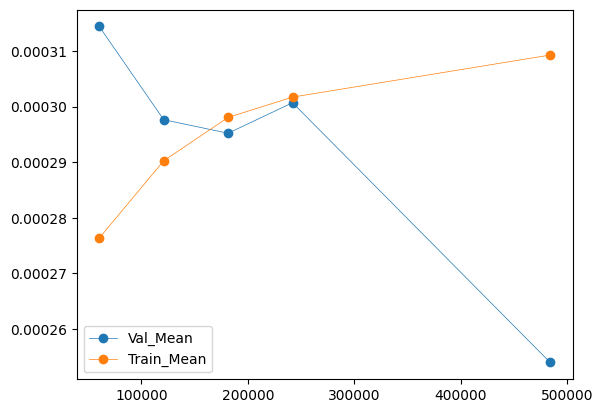

In [94]:
fig, ax = plt.subplots()
ax.plot(metrics_by_training_size['Mean'], marker = 'o', linestyle = '-', lw = 0.5, label = 'Val_Mean')
ax.plot(metrics_by_training_size['Train_Mean'], marker = 'o', linestyle = '-', lw = 0.5, label = 'Train_Mean')
ax.legend()
mean, std = metrics_by_training_size['Mean'], metrics_by_training_size['Std']
#ax.fill_between(metrics_by_training_size.index, mean - std, mean + std, alpha = 0.3) 

It is not clear what is the optimal training set size from this example alone. I'm not sure whether or not the data here is perhaps too noisy? But they seem to have similar standard deviation - so it's a bit confusing. 

In [78]:
len(df)/10

106272.0

In [77]:
14*TICKS_PER_DAY

120960

In [75]:
28*TICKS_PER_DAY

241920

In [ ]:
#Estimate ERR as a function of training set size by using walk-forward analysis, using OBI only - doubt it will make a difference 
TICKS_PER_DAY = 8640
models_by_training_size= {}
test_size = TICKS_PER_DAY*3
TRAINING_SIZES = [
    7*TICKS_PER_DAY, 
    14*TICKS_PER_DAY,
    21*TICKS_PER_DAY,
    28*TICKS_PER_DAY, 
    56*TICKS_PER_DAY, #2 months - lookback 
    ] 
temp_params = params 
for training_size in TRAINING_SIZES: 
    models_by_training_size[training_size] = sliding_window_cross_val(train_df, features = ['obi'], target = 'fwd_ret_3', xgb_params = params, train_size = training_size, test_size = test_size, cv = 'rolling')

## Iteration 1 - Initial implementation (using sliding window)

In [269]:
results_sliding= sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = params)

  0%|          | 0/10 [00:00<?, ?it/s][12:50:13] ======== Monitor (0): HostSketchContainer ========
[12:50:13] AllReduce: 0.001643s, 1 calls @ 1643us

[12:50:13] MakeCuts: 0.001728s, 1 calls @ 1728us

[12:50:13] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 49, 4163200).
[12:50:13] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[12:50:13] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[12:50:14] ======== Monitor (0): GBTree ========
[12:50:14] BoostNewTrees: 1.02452s, 100 calls @ 1024522us

[12:50:14] CommitModel: 3.4e-05s, 100 calls @ 34us

[12:50:14] ======== Monitor (0): HistUpdater ========
[12:50:14] BuildHistogram: 0.098185s, 500 calls @ 98185us

[12:50:14] EvaluateSplits: 0.088074s, 600 calls @ 88074us

[12:50:14] InitData: 0.00605s, 100 calls @ 6050us

[12:50:14] InitRoot: 0.05667s, 100 calls @ 5667

## Comparison (Non-Linear Model) - Instantaneous imbalance vs. complete feature set 

In [307]:
results_obi_only= sliding_window_cross_val(df, features = ['obi'], target = 'fwd_ret_3', xgb_params = params)
results_obi_only

  0%|          | 0/10 [00:00<?, ?it/s][14:44:40] ======== Monitor (0): HostSketchContainer ========
[14:44:40] AllReduce: 0.000388s, 1 calls @ 388us

[14:44:40] MakeCuts: 0.000444s, 1 calls @ 444us

[14:44:40] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 1, 85017).
[14:44:40] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[14:44:40] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[14:44:41] ======== Monitor (0): GBTree ========
[14:44:41] BoostNewTrees: 0.566685s, 100 calls @ 566685us

[14:44:41] CommitModel: 3.5e-05s, 100 calls @ 35us

[14:44:41] ======== Monitor (0): HistUpdater ========
[14:44:41] BuildHistogram: 0.074959s, 500 calls @ 74959us

[14:44:41] EvaluateSplits: 0.037832s, 600 calls @ 37832us

[14:44:41] InitData: 0.005456s, 100 calls @ 5456us

[14:44:41] InitRoot: 0.020441s, 100 calls @ 20441us

{'score': np.float64(2.449101782299322),
 'val_mean': np.float64(0.0002919573924799686),
 'val_scores': [0.00044540235584998166,
  0.0002125976667108167,
  0.000428026579159507,
  0.0004258090191760431,
  0.00020648854915997995,
  0.00023341276288830508,
  0.0001874862567605004,
  0.00023949658362473408,
  0.00011150894293120446,
  0.0004293452085386131],
 'train_scores': [0.00020938286604738974,
  0.00031125489173335546,
  0.0002364637586902751,
  0.0003218575670064559,
  0.00037353263132562555,
  0.0003208452620752863,
  0.00026942123354619545,
  0.00015145969852561523,
  0.00020255571429411522,
  0.00022810789763143212]}

In [274]:
results_obi_only['score']
results_sliding['score']

np.float64(2.449101782299322)

np.float64(2.3975945819890425)

In [276]:
results_obi_only['val_mean']
results_sliding['val_mean']

np.float64(0.0002919573924799686)

np.float64(0.00030548601245992875)

It is interesting that, after taking into account std in validation scores, adding in all features does better on average. However, note that this is not the case if we do not account for std deviation. 

### Comparison - Feature Set (Linear Model) - Instantaneous imbalance vs. total feature set 

In [278]:
train_df = df[:'2025-12-19']
len(train_df)

691200

In [285]:
results_linear_obi= sliding_window_cross_val(train_df, features = ['obi'], target = 'fwd_ret_3', model_type='linear')
results_linear_all_features = sliding_window_cross_val(train_df, feas_list, target = 'fwd_ret_3', model_type='linear')

100%|██████████| 10/10 [00:00<00:00, 23.32it/s]


In [309]:
results_linear_obi['score']
results_linear_all_features['score']

results_linear_obi['val_mean']
results_linear_all_features['val_mean']

np.float64(3.980175854792564)

np.float64(3.9757766443331723)

np.float64(0.0003204251575301347)

np.float64(0.00032087502674689125)

Our results are the same as for the non-linear space.

### Comparison - Non-linear model vs linear model 

In [ ]:
#using only obi - linear to non linear model 
results_linear_obi['score']
results_obi_only['score']

#using all features - linear to non-linear model 
results_linear_all_features['score']
results_sliding['score']

np.float64(3.980175854792564)

np.float64(2.449101782299322)

np.float64(3.9757766443331723)

np.float64(2.3975945819890425)

So the non-linear decision tree DOES deliver more predictive power if we account for standard deviatoin in k-fold cross validation. 

### Model Diagnostics 

Some immediate problems: 
- Once we account for the spread in validation scores, adding more features does benefit. But the spread in validation scores is somewhat bothersome, considering we have a huge sample size- why is taking the mean validation score not enough? 
  - Ideally, we want everything to ALIGN 
- How can we get a **sense of scale** for baseline performance/any performance?
- How can we tell if the results are actually SIGNICANT? (maybe deprecate that, for now)


Other ideas 
- Manaual error analysis 
- Feature importance 
- Adjust complexity of the model - needs the learning to be toggled slightly. 

#### Why does the answer change with k-fold scores? 

In [300]:
#Use 
results_all_features =  sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params= params, num_splits = 5)
results_obi_only = sliding_window_cross_val(df, features = ['obi'], target = 'fwd_ret_3', xgb_params = params, num_splits =5)

  0%|          | 0/5 [00:00<?, ?it/s][14:29:58] ======== Monitor (0): HostSketchContainer ========
[14:29:58] AllReduce: 0.002287s, 1 calls @ 2287us

[14:29:58] MakeCuts: 0.002404s, 1 calls @ 2404us

[14:29:58] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (170035, 49, 8329082).
[14:29:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[14:29:58] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[14:30:00] ======== Monitor (0): GBTree ========
[14:30:00] BoostNewTrees: 1.86323s, 100 calls @ 1863233us

[14:30:00] CommitModel: 7e-05s, 100 calls @ 70us

[14:30:00] ======== Monitor (0): HistUpdater ========
[14:30:00] BuildHistogram: 0.110583s, 500 calls @ 110583us

[14:30:00] EvaluateSplits: 0.09273s, 600 calls @ 92730us

[14:30:00] InitData: 0.005699s, 100 calls @ 5699us

[14:30:00] InitRoot: 0.080751s, 100 calls @ 8075

In [ ]:
results_all_features['val_mean']
results_obi_only['val_mean']

results_all_features['score']
results_obi_only['score']

np.float64(0.0002994884249428384)

np.float64(0.00029456876108707226)

np.float64(4.603575250979765)

np.float64(4.679762320840063)

#### Other improvements - how to add predictive power 

From looking at our results, we have that: 
- linear to non linear model - a boost in predictive power, for either OBI or all features 
- OBI to all features - neglible boost in predictive power, both for linear model and also decision tree. 
  - Moreover, the magnitude of improvement is comparable to the linear model 

Therefore, there are two possibilities: 
- Possibility 1: The decision tree does not have enough complexity to handle the modelling of all the new features, OR: 
- Possibility 2: The new features I have added in just really don't have that much predictive power, like at all 

In [447]:
#initial visualisation - feature importance 
results = sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = params, num_splits = 10)
results_obi_only = sliding_window_cross_val(df, features = ['obi'], target = 'fwd_ret_3', xgb_params = params, num_splits = 10)

  0%|          | 0/10 [00:00<?, ?it/s][11:01:11] ======== Monitor (0): HostSketchContainer ========
[11:01:11] AllReduce: 0.002003s, 1 calls @ 2003us

[11:01:11] MakeCuts: 0.002131s, 1 calls @ 2131us

[11:01:11] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 49, 4163200).
[11:01:11] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (21255, 49, 1041495).
[11:01:11] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[11:01:11] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[11:01:12] ======== Monitor (0): GBTree ========
[11:01:12] BoostNewTrees: 0.970207s, 100 calls @ 970207us

[11:01:12] CommitModel: 4.2e-05s, 100 calls @ 42us

[11:01:12] ======== Monitor (0): HistUpdater ========
[11:01:12] BuildHistogram: 0.095356s, 500 calls @ 95356us

[11

Not really sure how to make sense of these feature importance scores, to be honest - since they are like... averaged across folds? 

<Axes: title={'center': 'Feature Importance (Information Gain)'}, xlabel='Feature'>

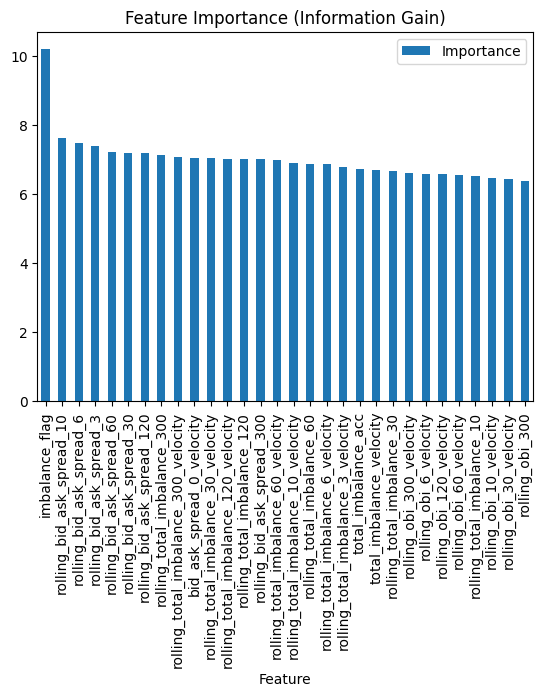

In [442]:
#note that feature importance is averaged across models 
importances = []
for m in results['models']:
    #idea - average feature importance across all k-folds
    temp_df =  pd.DataFrame.from_dict(m.get_booster().get_score(importance_type = 'gain'), orient = 'index').reset_index()
    temp_df.columns = ['Feature', 'Importance']
    importances.append(temp_df)

importances_df = pd.concat(importances).groupby('Feature').mean().sort_values(by = 'Importance', ascending=False)
importances_df.head(n=30).plot.bar(title = 'Feature Importance (Information Gain)')

In [540]:
list(importances_df.head(n=5).index)

['imbalance_flag',
 'rolling_bid_ask_spread_10',
 'rolling_bid_ask_spread_6',
 'rolling_bid_ask_spread_3',
 'rolling_bid_ask_spread_60']

If the situation looked more like Possibility 2, then we would expect obi to be at the top of feature importance, but this is not the case here. 

#### Learning curves 

The question we want to answer is: is our decision tree suffering from high bias?

In a traditional situation of high bias, the model is too simple, and therefore adding MORE data will not increase predictive accuracy after a certain point. In other words, the training error will PLATEAU after a certain point. Furthermore, the CV error and the training error will be "close" to each other. The traditional diagnostic is to plot the training error and the test set error vs. increasing training set size. 

However, the problem of training set learning curves is complicated in this situation by the fact that we STRONGLY suspect frequent regime shifting - see rolling correlation plot. 

#### Model Complexity 

In [335]:
results['models'][0].evals_result().keys()

dict_keys(['validation_0'])

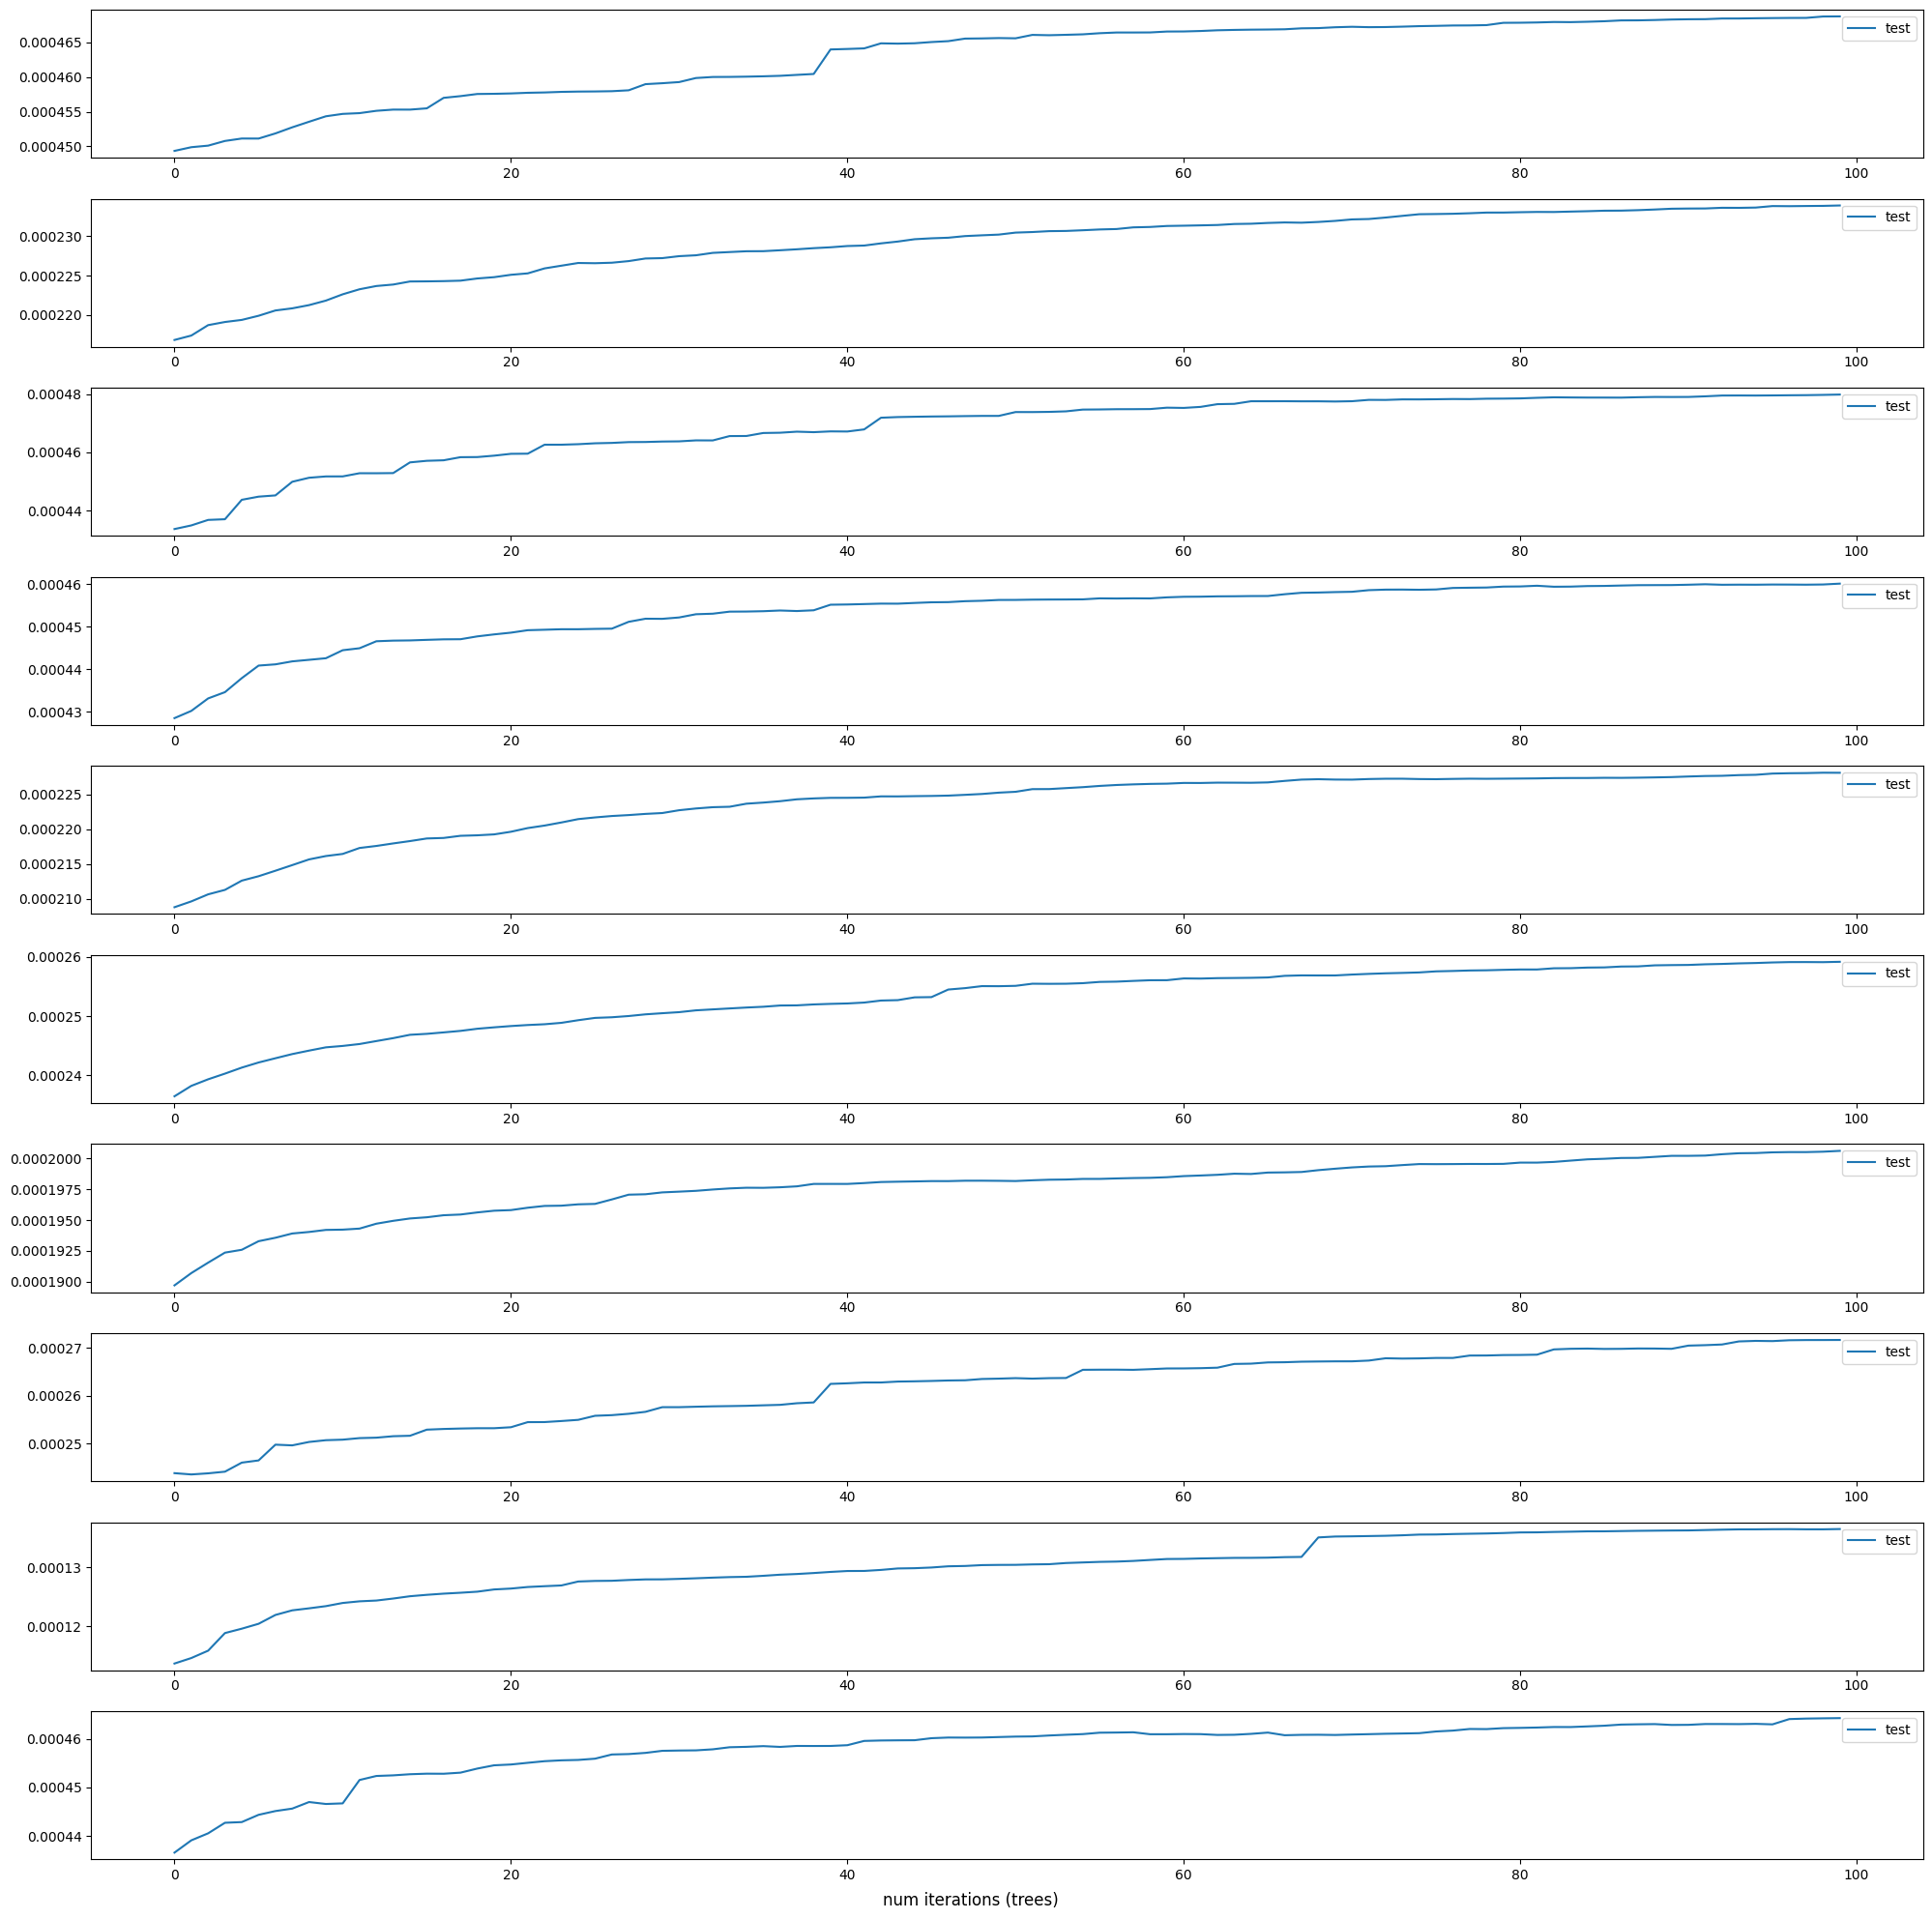

In [518]:
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(results['models']), figsize = (20, 20));
for m, a in zip(results['models'], ax): 
    scores= m.evals_result()
    #a.plot(scores['validation_0']['mae'], label = 'train');
    a.plot(scores['validation_1']['mae'], label = 'test');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

The training errror decreases as we add number of trees, which is as expected. However, the learning curves look like they are sloping downwards, so we should consider adding more trees. 

This is confusing and somewhat pathological - why is the test error actually SMALLER in some of the folds? This doesn't make a heap of sense - there is some kind of ... instability here, possibly within the training folds. It is quite unclear what the reason is. 

Checklist 
- Check the data distribution - any glaring/obvious errors? 
- Is it maybe the number of folds? 
  - Note - tested - does not remove error 

Other observations 
- Furthermore, neither the CV nor training error seems responsive to increasing number of trees 
- The gap between training and test does not seem to close/change much with number of tree iterations 

#### Toggle 1: Increasing max depth of the tree 

In [80]:
#Iteration 1 - Tree depth 
results_by_depth = {}
for max_depth in [4, 6, 8, 10, 12]: 
    temp_params = params.copy()
    temp_params['max_depth']= max_depth
    results_by_depth[max_depth] = sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = temp_params, num_splits = 10)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


[17:33:23] ======== Monitor (0): HostSketchContainer ========
[17:33:23] AllReduce: 0.001622s, 1 calls @ 1622us

[17:33:23] MakeCuts: 0.001705s, 1 calls @ 1705us

[17:33:23] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 49, 4163200).
[17:33:23] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (21255, 49, 1041495).
[17:33:23] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0


 10%|█         | 1/10 [00:01<00:09,  1.06s/it]

[17:33:24] ======== Monitor (0): GBTree ========
[17:33:24] BoostNewTrees: 0.891258s, 100 calls @ 891258us

[17:33:24] CommitModel: 3.1e-05s, 100 calls @ 31us

[17:33:24] ======== Monitor (0): HistUpdater ========
[17:33:24] BuildHistogram: 0.056261s, 300 calls @ 56261us

[17:33:24] EvaluateSplits: 0.038469s, 400 calls @ 38469us

[17:33:24] InitData: 0.005257s, 100 calls @ 5257us

[17:33:24] InitRoot: 0.053274s, 100 calls @ 53274us

[17:33:24] LeafPartition: 0.006616s, 100 calls @ 6616us

[17:33:24] UpdatePosition: 0.045787s, 400 calls @ 45787us

[17:33:24] UpdatePredictionCache: 0.007238s, 100 calls @ 7238us

[17:33:24] UpdateTree: 0.199387s, 100 calls @ 199387us

[17:33:24] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:33:24] ======== Monitor (0): HostSketchContainer ========
[17:33:24] AllReduce: 0.001549s, 1 calls @ 1549us

[17:33:24] MakeCuts: 0.001634s, 1 calls @ 1634us

[17:33:24] INFO: /Users/runner/work/xgboost/xgboost/src/data/itera

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:33:24] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
 20%|██        | 2/10 [00:02<00:08,  1.05s/it]

...

[17:34:29] ======== Monitor (0): GBTree ========
[17:34:29] BoostNewTrees: 1.77282s, 100 calls @ 1772818us

[17:34:29] CommitModel: 4.2e-05s, 100 calls @ 42us

[17:34:29] ======== Monitor (0): HistUpdater ========
[17:34:29] BuildHistogram: 0.376356s, 1110 calls @ 376356us

[17:34:29] EvaluateSplits: 0.547482s, 1210 calls @ 547482us

[17:34:29] InitData: 0.009995s, 100 calls @ 9995us

[17:34:29] InitRoot: 0.043993s, 100 calls @ 43993us

[17:34:29] LeafPartition: 0.007852s, 100 calls @ 7852us

[17:34:29] UpdatePosition: 0.131888s, 1225 calls @ 131888us

[17:34:29] UpdatePredictionCache: 0.007853s, 100 calls @ 7853us

[17:34:29] UpdateTree: 1.13152s, 100 calls @ 1131517us

[17:34:29] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:34:29] ======== Monitor (0): HostSketchContainer ========
[17:34:29] AllReduce: 0.001762s, 1 calls @ 1762us

[17:34:29] MakeCuts: 0.001866s, 1 calls @ 1866us

[17:34:29] INFO: /Users/runner/work/xgboost/xgboost/src/data

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:34:29] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
 90%|█████████ | 9/10 [00:17<00:01,  1.98s/it]

[17:34:31] ======== Monitor (0): GBTree ========
[17:34:31] BoostNewTrees: 1.83499s, 100 calls @ 1834990us

[17:34:31] CommitModel: 3.9e-05s, 100 calls @ 39us

[17:34:31] ======== Monitor (0): HistUpdater ========
[17:34:31] BuildHistogram: 0.362543s, 1108 calls @ 362543us

[17:34:31] EvaluateSplits: 0.52992s, 1208 calls @ 529920us

[17:34:31] InitData: 0.013969s, 100 calls @ 13969us

[17:34:31] InitRoot: 0.044202s, 100 calls @ 44202us

[17:34:31] LeafPartition: 0.007794s, 100 calls @ 7794us

[17:34:31] UpdatePosition: 0.132725s, 1219 calls @ 132725us

[17:34:31] UpdatePredictionCache: 0.007924s, 100 calls @ 7924us

[17:34:31] UpdateTree: 1.10278s, 100 calls @ 1102783us

[17:34:31] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:34:31] ======== Monitor (0): HostSketchContainer ========
[17:34:31] AllReduce: 0.002323s, 1 calls @ 2323us

[17:34:31] MakeCuts: 0.002411s, 1 calls @ 2411us

[17:34:31] INFO: /Users/runner/work/xgboost/xgboost/src/data

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:34:31] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
100%|██████████| 10/10 [00:19<00:00,  1.99s/it]

[17:34:33] ======== Monitor (0): GBTree ========
[17:34:33] BoostNewTrees: 1.80463s, 100 calls @ 1804631us

[17:34:33] CommitModel: 3.8e-05s, 100 calls @ 38us

[17:34:33] ======== Monitor (0): HistUpdater ========
[17:34:33] BuildHistogram: 0.362421s, 1107 calls @ 362421us

[17:34:33] EvaluateSplits: 0.530927s, 1207 calls @ 530927us

[17:34:33] InitData: 0.012057s, 100 calls @ 12057us

[17:34:33] InitRoot: 0.044183s, 100 calls @ 44183us

[17:34:33] LeafPartition: 0.007932s, 100 calls @ 7932us

[17:34:33] UpdatePosition: 0.133907s, 1219 calls @ 133907us

[17:34:33] UpdatePredictionCache: 0.00798s, 100 calls @ 7980us

[17:34:33] UpdateTree: 1.10415s, 100 calls @ 1104147us

[17:34:33] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0


In [474]:
for max_depth, results in results_by_depth.items(): 
    print(f"Training score for depth: {max_depth}: {np.mean(results['train_scores']/np.std(results['train_scores']))}")

for max_depth, results in results_by_depth.items(): 
    print(f"CV Score for depth: {max_depth}: {results['score']}")

Training score for depth: 4: 4.173609506382331
Training score for depth: 6: 4.292051072805401
Training score for depth: 8: 4.316058742152895
Training score for depth: 10: 4.349810885522362
Training score for depth: 12: 4.294011996597643
CV Score for depth: 4: 2.4067418320528366
CV Score for depth: 6: 2.3975945819890425
CV Score for depth: 8: 2.4689650750727887
CV Score for depth: 10: 2.4992868057396476
CV Score for depth: 12: 2.5489381885644122


So, all else being equal, performance does not improve as we add more tree depth. This is also the case for training scores. 

In [83]:
### Toggle 2: Increase number of training iterations 

results_by_num_trees = {}
for num_trees in [500, 1000]: 
    temp_params = params.copy()
    temp_params['n_estimators'] = num_trees
    results_by_num_trees[num_trees] = sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = temp_params, num_splits = 10)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:35:29] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


[17:35:29] ======== Monitor (0): HostSketchContainer ========
[17:35:29] AllReduce: 0.001986s, 1 calls @ 1986us

[17:35:29] MakeCuts: 0.002067s, 1 calls @ 2067us

[17:35:29] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 49, 4163200).
[17:35:29] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (21255, 49, 1041495).
[17:35:29] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0


 10%|█         | 1/10 [00:05<00:52,  5.88s/it]

[17:35:35] ======== Monitor (0): GBTree ========
[17:35:35] BoostNewTrees: 5.40563s, 500 calls @ 5405633us

[17:35:35] CommitModel: 0.000174s, 500 calls @ 174us

[17:35:35] ======== Monitor (0): HistUpdater ========
[17:35:35] BuildHistogram: 0.442616s, 2500 calls @ 442616us

[17:35:35] EvaluateSplits: 0.380162s, 3000 calls @ 380162us

[17:35:35] InitData: 0.027065s, 500 calls @ 27065us

[17:35:35] InitRoot: 0.268646s, 500 calls @ 268646us

[17:35:35] LeafPartition: 0.035635s, 500 calls @ 35635us

[17:35:35] UpdatePosition: 0.340694s, 3000 calls @ 340694us

[17:35:35] UpdatePredictionCache: 0.035728s, 500 calls @ 35728us

[17:35:35] UpdateTree: 1.46804s, 500 calls @ 1468036us

[17:35:35] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:35:35] ======== Monitor (0): HostSketchContainer ========
[17:35:35] AllReduce: 0.001538s, 1 calls @ 1538us

[17:35:35] MakeCuts: 0.001607s, 1 calls @ 1607us

[17:35:35] INFO: /Users/runner/work/xgboost/xgboost/sr

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:35:35] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
 20%|██        | 2/10 [00:11<00:47,  5.92s/it]

...

[17:37:59] ======== Monitor (0): GBTree ========
[17:37:59] BoostNewTrees: 6.54635s, 1000 calls @ 6546352us

[17:37:59] CommitModel: 0.000243s, 1000 calls @ 243us

[17:37:59] ======== Monitor (0): HistUpdater ========
[17:37:59] BuildHistogram: 1.09573s, 5000 calls @ 1095732us

[17:37:59] EvaluateSplits: 0.713971s, 6000 calls @ 713971us

[17:37:59] InitData: 0.051829s, 1000 calls @ 51829us

[17:37:59] InitRoot: 0.435327s, 1000 calls @ 435327us

[17:37:59] LeafPartition: 0.067539s, 1000 calls @ 67539us

[17:37:59] UpdatePosition: 0.602307s, 6000 calls @ 602307us

[17:37:59] UpdatePredictionCache: 0.067739s, 1000 calls @ 67739us

[17:37:59] UpdateTree: 2.93222s, 1000 calls @ 2932221us

[17:37:59] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:37:59] ======== Monitor (0): HostSketchContainer ========
[17:37:59] AllReduce: 0.001777s, 1 calls @ 1777us

[17:37:59] MakeCuts: 0.00187s, 1 calls @ 1870us

[17:37:59] INFO: /Users/runner/work/xgboost/xgbo

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:37:59] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
 90%|█████████ | 9/10 [01:44<00:11, 11.02s/it]

[17:38:11] ======== Monitor (0): GBTree ========
[17:38:11] BoostNewTrees: 10.9673s, 1000 calls @ 10967276us

[17:38:11] CommitModel: 0.000356s, 1000 calls @ 356us

[17:38:11] ======== Monitor (0): HistUpdater ========
[17:38:11] BuildHistogram: 0.904657s, 5000 calls @ 904657us

[17:38:11] EvaluateSplits: 0.694719s, 6000 calls @ 694719us

[17:38:11] InitData: 0.057519s, 1000 calls @ 57519us

[17:38:11] InitRoot: 0.480578s, 1000 calls @ 480578us

[17:38:11] LeafPartition: 0.068871s, 1000 calls @ 68871us

[17:38:11] UpdatePosition: 0.650819s, 6000 calls @ 650819us

[17:38:11] UpdatePredictionCache: 0.072517s, 1000 calls @ 72517us

[17:38:11] UpdateTree: 2.8202s, 1000 calls @ 2820198us

[17:38:11] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[17:38:11] ======== Monitor (0): HostSketchContainer ========
[17:38:11] AllReduce: 0.001597s, 1 calls @ 1597us

[17:38:11] MakeCuts: 0.00169s, 1 calls @ 1690us

[17:38:11] INFO: /Users/runner/work/xgboost/xgbo

/Users/vivbear/Documents/Quant_Research/Projects/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:38:11] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
 90%|█████████ | 9/10 [01:55<00:12, 12.78s/it]


KeyboardInterrupt: 

In [81]:
temp_results = results_by_num_trees[1000]
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(temp_results['models']), figsize = (20, 20));
for m, a in zip(temp_results['models'], ax): 
    scores= m.evals_result()
    #a.plot(scores['validation_0']['mae'], label = 'train');
    a.plot(scores['validation_1']['mae'], label = 'test');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

NameError: name 'results_by_num_trees' is not defined

In [481]:
results['score']
results_by_num_trees[500]['score']
results_by_num_trees[1000]['score']

np.float64(2.5489381885644122)

np.float64(2.363991643394997)

np.float64(2.367962388936657)

Still does not look like it has plateaued significantly yet, even with 1000 tree iterations - should probably consider toggling the learning rate. 

### Adjust - Learning Rate (for equivalent/same number of trees)

In [486]:
temp_params = params.copy()
temp_params['n_estimators'] = 500
temp_params['learning_rate'] = 0.6
temp_results =  sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = temp_params, num_splits = 10)

  0%|          | 0/10 [00:00<?, ?it/s][12:02:50] ======== Monitor (0): HostSketchContainer ========
[12:02:50] AllReduce: 0.001548s, 1 calls @ 1548us

[12:02:50] MakeCuts: 0.001638s, 1 calls @ 1638us

[12:02:50] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (85017, 49, 4163200).
[12:02:50] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (21255, 49, 1041495).
[12:02:50] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[12:02:50] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[12:02:56] ======== Monitor (0): GBTree ========
[12:02:56] BoostNewTrees: 5.31996s, 500 calls @ 5319955us

[12:02:56] CommitModel: 0.000164s, 500 calls @ 164us

[12:02:56] ======== Monitor (0): HistUpdater ========
[12:02:56] BuildHistogram: 0.445186s, 2500 calls @ 445186us


In [493]:
results['score']
results_by_num_trees[500]['score']
temp_results['score']

np.float64(2.5489381885644122)

np.float64(2.363991643394997)

np.float64(2.442361203551129)

In [79]:
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(temp_results['models']), figsize = (20, 20));
for m, a in zip(temp_results['models'], ax): 
    scores= m.evals_result()
    a.plot(scores['validation_0']['mae'], label = 'train');
    a.plot(scores['validation_1']['mae'], label = 'test');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

NameError: name 'temp_results' is not defined

In [ ]:
ETA = [0.05, 0.1, 0.5, 0.75, 1]
NUM_TREES = [100, 500, 1_000, 2_000]
results_by_eta_num_trees = {}

for eta, num_trees in product(ETA, NUM_TREES): 
    temp_params = params.copy()
    temp_params['n_estimators'] = num_trees
    temp_params['learning_rate'] = eta 
    results_by_eta_num_trees[(eta, num_trees)] = sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = temp_params, num_splits = 10)

0.05 100
0.05 500
0.05 1000
0.1 100
0.1 500
0.1 1000
0.5 100
0.5 500
0.5 1000
1 100
1 500
1 1000


#### Debug - Why is training error > test error? And why is there such a bizarre shape? 

In [ ]:
#Use expanding window CV 
results_all_features = sliding_window_cross_val(df, features = feas_list, target = 'fwd_ret_3', xgb_params = params, num_splits = 5, sliding=False)
results_obi_only = sliding_window_cross_val(df, features = ['obi'], target = 'fwd_ret_3', xgb_params = params, num_splits = 5, sliding=False)

Using expanding window split


  0%|          | 0/5 [00:00<?, ?it/s][16:43:57] ======== Monitor (0): HostSketchContainer ========
[16:43:57] AllReduce: 0.003165s, 1 calls @ 3165us

[16:43:57] MakeCuts: 0.003249s, 1 calls @ 3249us

[16:43:58] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (177122, 49, 8676345).
[16:43:58] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (177119, 49, 8678831).
[16:43:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[16:43:58] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[16:44:00] ======== Monitor (0): GBTree ========
[16:44:00] BoostNewTrees: 1.90399s, 100 calls @ 1903994us

[16:44:00] CommitModel: 5.3e-05s, 100 calls @ 53us

[16:44:00] ======== Monitor (0): HistUpdater ========
[16:44:00] BuildHistogram: 0.110271s, 500 calls @ 110271us

[

Using expanding window split


  0%|          | 0/5 [00:00<?, ?it/s][16:44:30] ======== Monitor (0): HostSketchContainer ========
[16:44:30] AllReduce: 0.000769s, 1 calls @ 769us

[16:44:30] MakeCuts: 0.000822s, 1 calls @ 822us

[16:44:30] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (177122, 1, 177122).
[16:44:30] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (177119, 1, 177119).
[16:44:30] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
[16:44:30] DEBUG: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:131: Using tree method: 0
[16:44:31] ======== Monitor (0): GBTree ========
[16:44:31] BoostNewTrees: 1.02217s, 100 calls @ 1022168us

[16:44:31] CommitModel: 2.4e-05s, 100 calls @ 24us

[16:44:31] ======== Monitor (0): HistUpdater ========
[16:44:31] BuildHistogram: 0.078693s, 500 calls @ 78693us

[16:44:3

In [506]:
results_all_features['score']
results_obi_only['score']

np.float64(4.461789271183133)

np.float64(2.449101782299322)

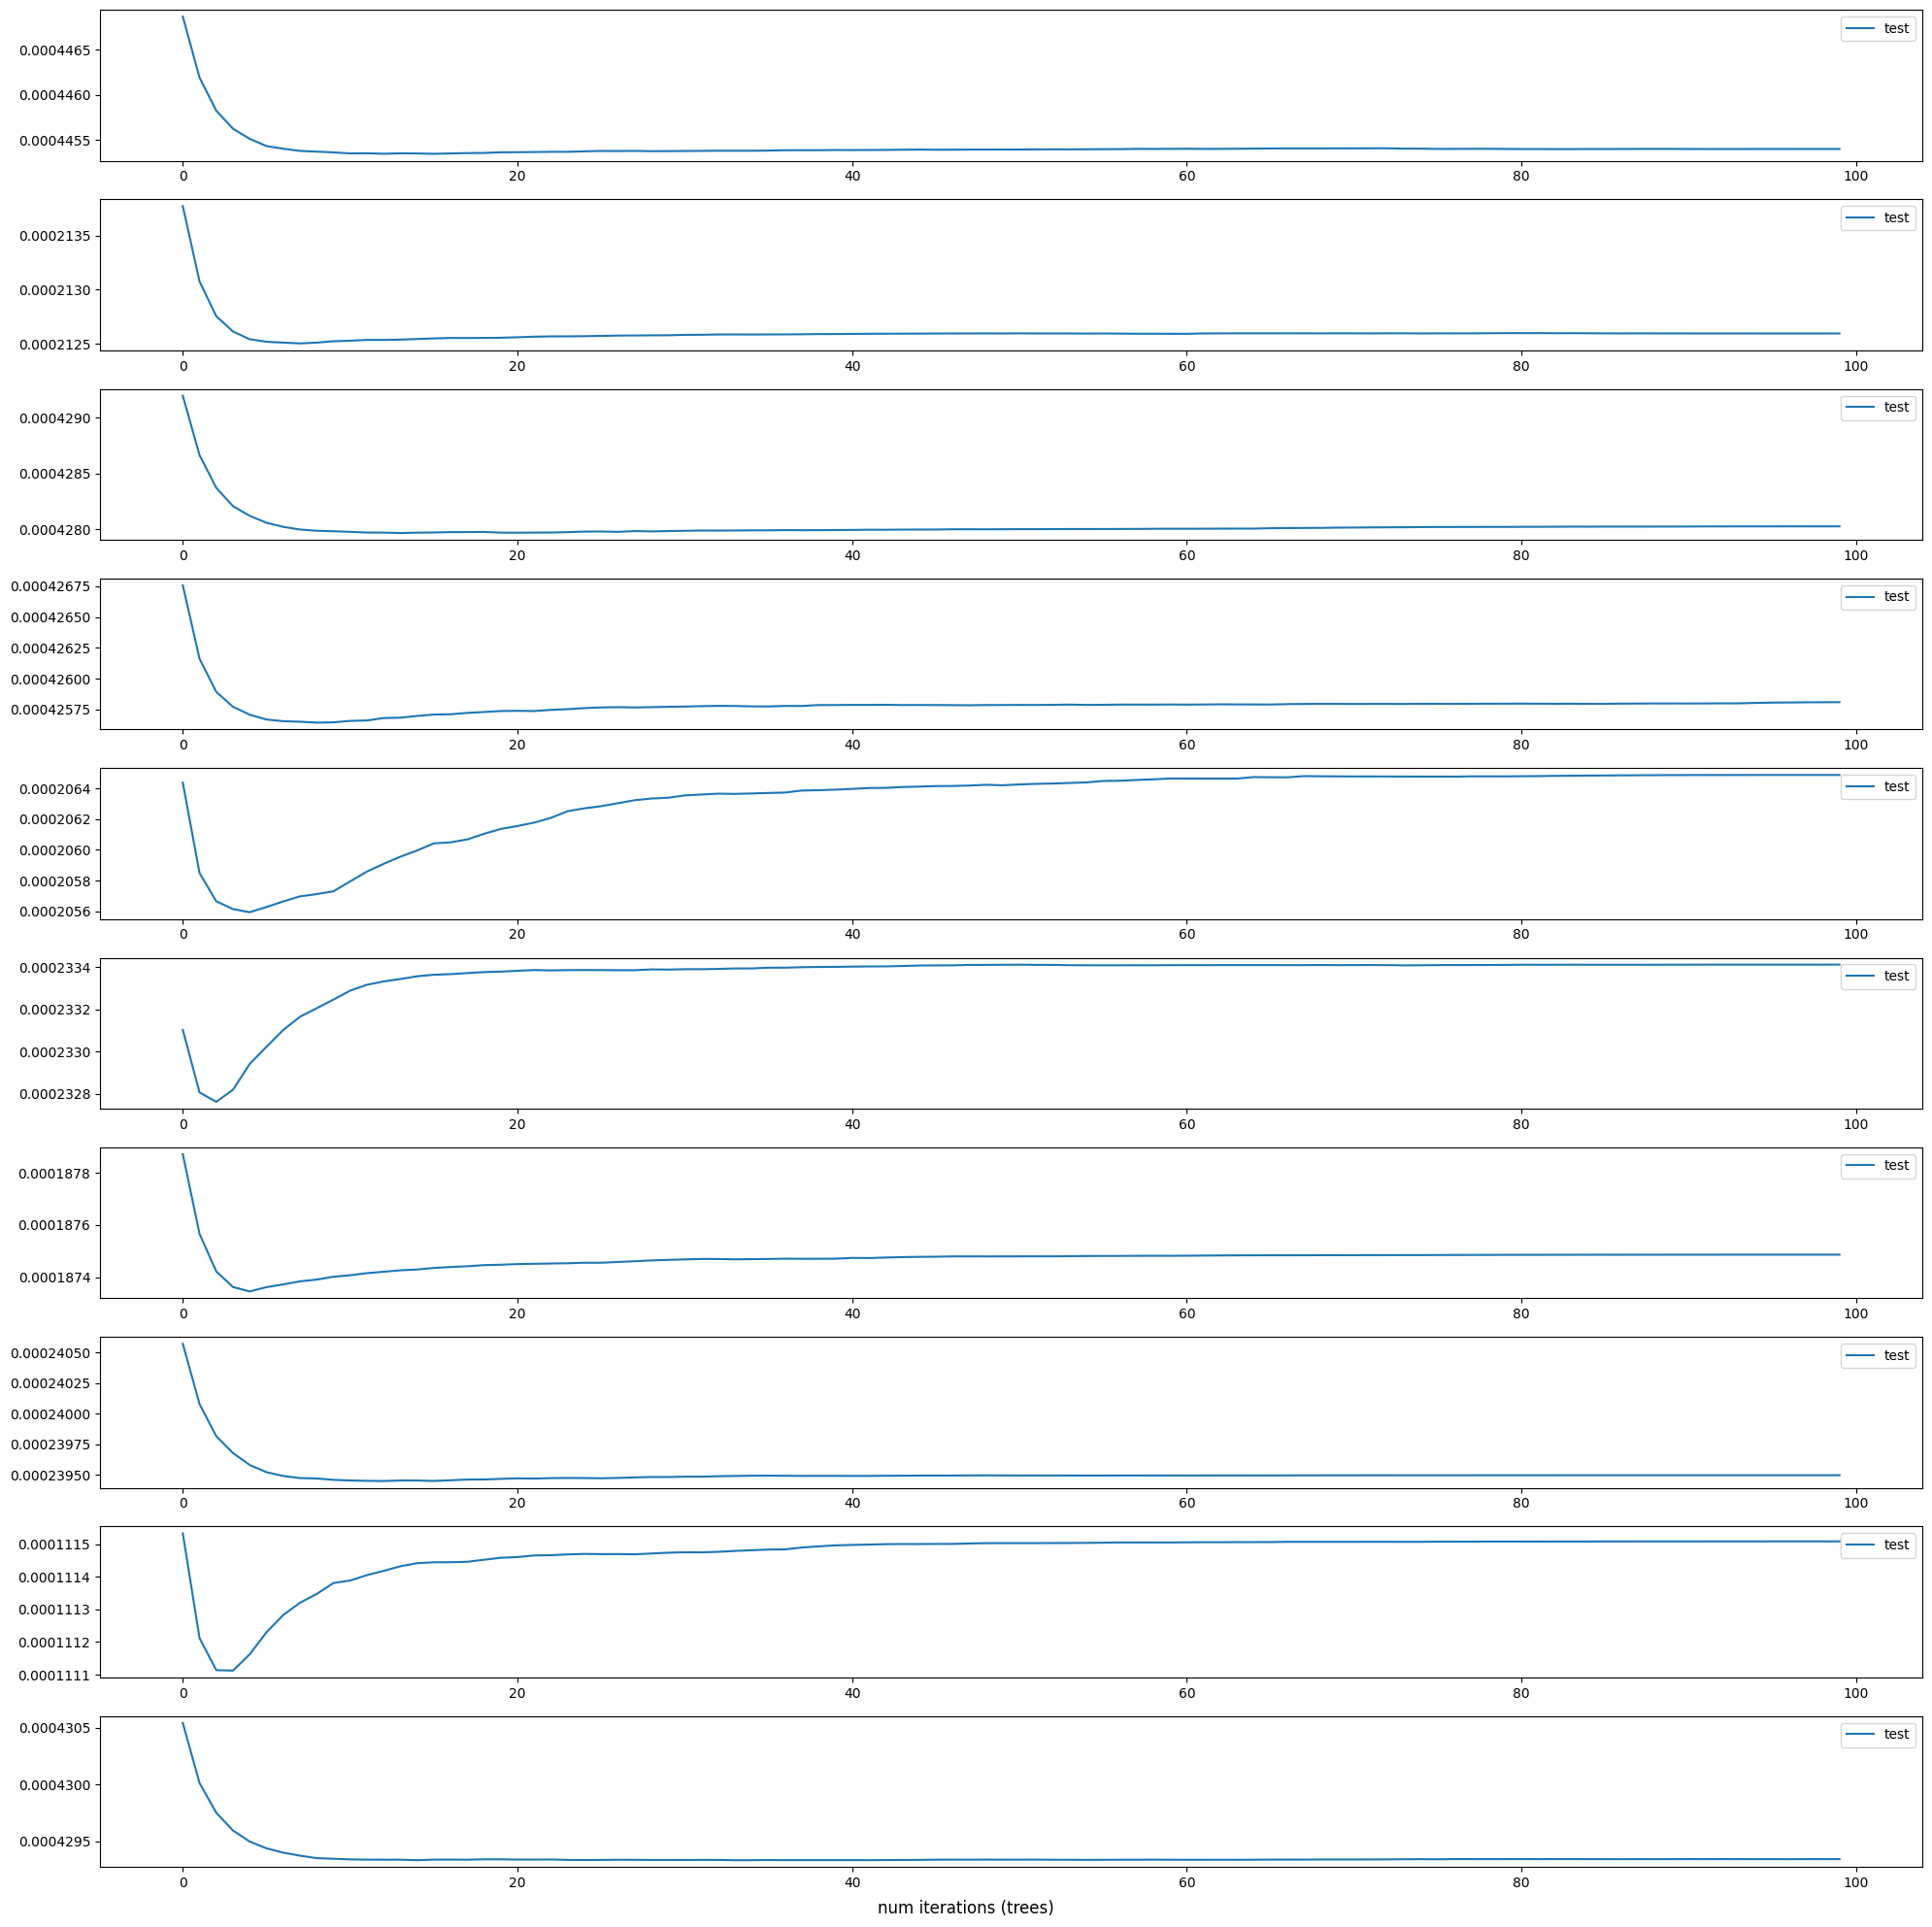

In [517]:
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(results_obi_only['models']), figsize = (20, 20));
for m, a in zip(results_obi_only['models'], ax): 
    scores= m.evals_result()
    #a.plot(scores['validation_0']['mae'], label = 'train');
    a.plot(scores['validation_1']['mae'], label = 'test');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

Note that expanding window does not make an impact on this bizarre result. This seems to also be the case for the linear model as well. 

# Question - Why is cross_val > train val for the data? 